# == 1. Prediksi Kecelakaan Kerja — PT Besli Menggunakan Metode Naive-Bayes ==

---

**Nama**            : Aldon Zufar Putra T <br>
**Kelas**           : Robotika-B Pagi <br>
**Semester**        : 6 <br>
**Urutan Absensi**  : 10 <br>
**Studi Kasus**     : Studi Kasus 1 [Absensi 1-10] <br>

---

**Metode:** Naive Bayes Classifier dengan Laplace Smoothing  
**Dataset:** `dataset_kecelakaan.csv` (300 data karyawan)  
**Target:** `Kecelakaan` (1 = Pernah mengalami kecelakaan kerja, 0 = Tidak)

---

### Fitur Dataset
| Fitur | Tipe | Keterangan |
|---|---|---|
| Usia | Numerik → Kategori | Usia karyawan (tahun) |
| Jam_Kerja_per_Minggu | Numerik → Kategori | Jam kerja per minggu |
| Pengalaman_Tahun | Numerik → Kategori | Lama pengalaman kerja |
| Pelatihan_K3 | Kategorikal | Ya / Tidak (sudah mengikuti pelatihan K3) |
| Shift | Kategorikal | Pagi / Siang / Malam |
| Jabatan | Kategorikal | Operator / Supervisor / Manager |
| Lokasi | Kategorikal | Produksi / Gudang / Quality_Control |

## Import Library & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('dataset_kecelakaan.csv')

print(f'Shape      : {df.shape}')
print(f'Kolom      : {list(df.columns)}')
print(f'Missing    : {df.isnull().sum().sum()}')
print()
# df.head(50)
df.head(20)

Shape      : (300, 9)
Kolom      : ['ID', 'Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun', 'Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi', 'Kecelakaan']
Missing    : 0



,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0
5,6,58,49,17,Tidak,Siang,Manager,Gudang,0
6,7,38,46,13,Tidak,Siang,Operator,Gudang,0
7,8,42,38,20,Tidak,Siang,Operator,Quality_Control,1
8,9,65,45,25,Ya,Siang,Operator,Gudang,0
9,10,30,46,4,Tidak,Siang,Supervisor,Quality_Control,0


## Eksplorasi Data (EDA)

In [3]:
print('=' * 55)
print('INFORMASI DATASET')
print('=' * 55)
df.info()
print()
print('=' * 55)
print('STATISTIK DESKRIPTIF (Fitur Numerik)')
print('=' * 55)
display(df[['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']].describe().round(2))

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    300 non-null    int64
 1   Usia                  300 non-null    int64
 2   Jam_Kerja_per_Minggu  300 non-null    int64
 3   Pengalaman_Tahun      300 non-null    int64
 4   Pelatihan_K3          300 non-null    str  
 5   Shift                 300 non-null    str  
 6   Jabatan               300 non-null    str  
 7   Lokasi                300 non-null    str  
 8   Kecelakaan            300 non-null    int64
dtypes: int64(5), str(4)
memory usage: 28.8 KB

STATISTIK DESKRIPTIF (Fitur Numerik)


,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun
count,300.00,300.00,300.00
mean,40.38,44.78,17.75
std,12.12,6.60,10.93
min,15.00,10.00,1.00
25%,30.00,41.00,8.00
50%,42.00,45.00,18.00
75%,51.00,48.00,27.00
max,70.00,100.00,60.00


In [4]:
print('=' * 55)
print('DISTRIBUSI TARGET: Kecelakaan')
print('=' * 55)
kelas = df['Kecelakaan'].value_counts()
print(f"Tidak Kecelakaan (0) : {kelas[0]} karyawan ({kelas[0]/len(df)*100:.1f}%)")
print(f"Kecelakaan      (1) : {kelas[1]} karyawan ({kelas[1]/len(df)*100:.1f}%)")
print()

print('=' * 55)
print('DISTRIBUSI FITUR KATEGORIKAL')
print('=' * 55)
for col in ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']:
    print(f'\n{col}:')
    tbl = df.groupby([col, 'Kecelakaan']).size().unstack(fill_value=0)
    tbl.columns = ['Tidak Kecelakaan', 'Kecelakaan']
    tbl['Total'] = tbl.sum(axis=1)
    tbl['% Kecelakaan'] = (tbl['Kecelakaan'] / tbl['Total'] * 100).round(1)
    display(tbl)

DISTRIBUSI TARGET: Kecelakaan
Tidak Kecelakaan (0) : 216 karyawan (72.0%)
Kecelakaan      (1) : 84 karyawan (28.0%)

DISTRIBUSI FITUR KATEGORIKAL

Pelatihan_K3:


,Tidak Kecelakaan,Kecelakaan,Total,% Kecelakaan
Pelatihan_K3,,,,
Tidak,100,43,143,30.1
Ya,116,41,157,26.1



Shift:


,Tidak Kecelakaan,Kecelakaan,Total,% Kecelakaan
Shift,,,,
Malam,69,26,95,27.4
Pagi,75,34,109,31.2
Siang,72,24,96,25.0



Jabatan:


,Tidak Kecelakaan,Kecelakaan,Total,% Kecelakaan
Jabatan,,,,
Manager,67,25,92,27.2
Operator,69,28,97,28.9
Supervisor,80,31,111,27.9



Lokasi:


,Tidak Kecelakaan,Kecelakaan,Total,% Kecelakaan
Lokasi,,,,
Gudang,79,26,105,24.8
Produksi,78,26,104,25.0
Quality_Control,59,32,91,35.2


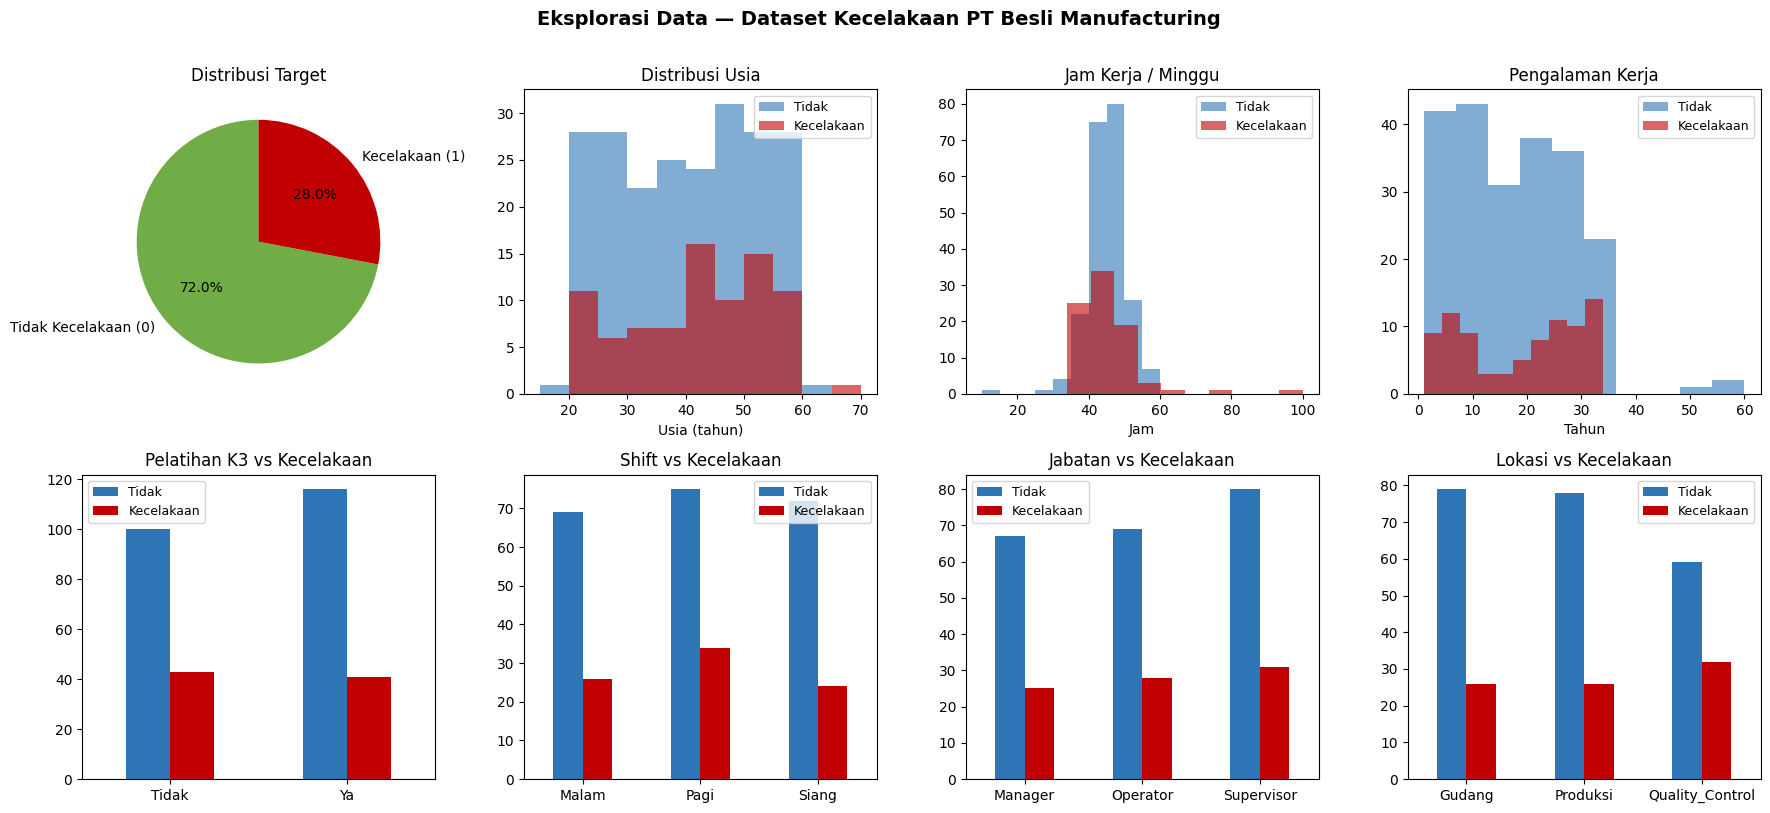

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Eksplorasi Data — Dataset Kecelakaan PT Besli Manufacturing',
             fontsize=14, fontweight='bold', y=1.01)

C0, C1 = '#2E75B6', '#C00000'

# Distribusi kelas
kelas_val = df['Kecelakaan'].value_counts()
axes[0,0].pie(kelas_val, labels=['Tidak Kecelakaan (0)', 'Kecelakaan (1)'],
              colors=['#70AD47', '#C00000'], autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribusi Target')

# Usia
for cls, c, lbl in [(0, C0, 'Tidak'), (1, C1, 'Kecelakaan')]:
    axes[0,1].hist(df[df['Kecelakaan']==cls]['Usia'], bins=10, alpha=0.6, color=c, label=lbl)
axes[0,1].set_title('Distribusi Usia')
axes[0,1].set_xlabel('Usia (tahun)')
axes[0,1].legend(fontsize=9)

# Jam Kerja
for cls, c, lbl in [(0, C0, 'Tidak'), (1, C1, 'Kecelakaan')]:
    axes[0,2].hist(df[df['Kecelakaan']==cls]['Jam_Kerja_per_Minggu'], bins=10, alpha=0.6, color=c, label=lbl)
axes[0,2].set_title('Jam Kerja / Minggu')
axes[0,2].set_xlabel('Jam')
axes[0,2].legend(fontsize=9)

# Pengalaman
for cls, c, lbl in [(0, C0, 'Tidak'), (1, C1, 'Kecelakaan')]:
    axes[0,3].hist(df[df['Kecelakaan']==cls]['Pengalaman_Tahun'], bins=10, alpha=0.6, color=c, label=lbl)
axes[0,3].set_title('Pengalaman Kerja')
axes[0,3].set_xlabel('Tahun')
axes[0,3].legend(fontsize=9)

# Pelatihan K3
pk = df.groupby(['Pelatihan_K3', 'Kecelakaan']).size().unstack(fill_value=0)
pk.plot(kind='bar', ax=axes[1,0], color=[C0, C1], rot=0)
axes[1,0].set_title('Pelatihan K3 vs Kecelakaan')
axes[1,0].legend(['Tidak', 'Kecelakaan'], fontsize=9)
axes[1,0].set_xlabel('')

# Shift
sh = df.groupby(['Shift', 'Kecelakaan']).size().unstack(fill_value=0)
sh.plot(kind='bar', ax=axes[1,1], color=[C0, C1], rot=0)
axes[1,1].set_title('Shift vs Kecelakaan')
axes[1,1].legend(['Tidak', 'Kecelakaan'], fontsize=9)
axes[1,1].set_xlabel('')

# Jabatan
jb = df.groupby(['Jabatan', 'Kecelakaan']).size().unstack(fill_value=0)
jb.plot(kind='bar', ax=axes[1,2], color=[C0, C1], rot=0)
axes[1,2].set_title('Jabatan vs Kecelakaan')
axes[1,2].legend(['Tidak', 'Kecelakaan'], fontsize=9)
axes[1,2].set_xlabel('')

# Lokasi
lk = df.groupby(['Lokasi', 'Kecelakaan']).size().unstack(fill_value=0)
lk.plot(kind='bar', ax=axes[1,3], color=[C0, C1], rot=0)
axes[1,3].set_title('Lokasi vs Kecelakaan')
axes[1,3].legend(['Tidak', 'Kecelakaan'], fontsize=9)
axes[1,3].set_xlabel('')

plt.tight_layout()
plt.show()

## Persiapan Data — Diskritisasi Fitur Numerik

Naive Bayes Kategorik membutuhkan semua fitur dalam bentuk kategori.  
Ketiga fitur numerik akan dibagi ke dalam bin yang bermakna:

| Fitur | Bins | Label |
|---|---|---|
| Usia | ≤25, 26–40, 41–55, >55 | Muda, Dewasa, Setengah Baya, Senior |
| Jam_Kerja_per_Minggu | ≤35, 36–45, >45 | Ringan, Normal, Berat |
| Pengalaman_Tahun | ≤5, 6–15, 16–30, >30 | Junior, Menengah, Senior, Veteran |

In [6]:
# Diskritisasi Usia
df['Usia_Cat'] = pd.cut(
    df['Usia'],
    bins=[0, 25, 40, 55, 100],
    labels=['Muda (≤25)', 'Dewasa (26-40)', 'Setengah Baya (41-55)', 'Senior (>55)']
)

# Diskritisasi Jam Kerja
df['Jam_Cat'] = pd.cut(
    df['Jam_Kerja_per_Minggu'],
    bins=[0, 35, 45, 200],
    labels=['Ringan (≤35)', 'Normal (36-45)', 'Berat (>45)']
)

# Diskritisasi Pengalaman
df['Pengalaman_Cat'] = pd.cut(
    df['Pengalaman_Tahun'],
    bins=[0, 5, 15, 30, 100],
    labels=['Junior (≤5)', 'Menengah (6-15)', 'Senior (16-30)', 'Veteran (>30)']
)

print('Distribusi Usia_Cat:')
print(df['Usia_Cat'].value_counts().sort_index(), '\n')
print('Distribusi Jam_Cat:')
print(df['Jam_Cat'].value_counts().sort_index(), '\n')
print('Distribusi Pengalaman_Cat:')
print(df['Pengalaman_Cat'].value_counts().sort_index())

df[['Usia', 'Usia_Cat', 'Jam_Kerja_per_Minggu', 'Jam_Cat',
    'Pengalaman_Tahun', 'Pengalaman_Cat', 'Kecelakaan']].head(10)

Distribusi Usia_Cat:
Usia_Cat
Muda (≤25)                47
Dewasa (26-40)            94
Setengah Baya (41-55)    125
Senior (>55)              34
Name: count, dtype: int64 

Distribusi Jam_Cat:
Jam_Cat
Ringan (≤35)        9
Normal (36-45)    164
Berat (>45)       127
Name: count, dtype: int64 

Distribusi Pengalaman_Cat:
Pengalaman_Cat
Junior (≤5)         49
Menengah (6-15)     89
Senior (16-30)     122
Veteran (>30)       40
Name: count, dtype: int64


,Usia,Usia_Cat,Jam_Kerja_per_Minggu,Jam_Cat,Pengalaman_Tahun,Pengalaman_Cat,Kecelakaan
0,58,Senior (>55),47,Berat (>45),10,Menengah (6-15),0
1,48,Setengah Baya (41-55),44,Normal (36-45),17,Senior (16-30),0
2,34,Dewasa (26-40),40,Normal (36-45),22,Senior (16-30),0
3,27,Dewasa (26-40),37,Normal (36-45),26,Senior (16-30),0
4,40,Dewasa (26-40),42,Normal (36-45),25,Senior (16-30),0
5,58,Senior (>55),49,Berat (>45),17,Senior (16-30),0
6,38,Dewasa (26-40),46,Berat (>45),13,Menengah (6-15),0
7,42,Setengah Baya (41-55),38,Normal (36-45),20,Senior (16-30),1
8,65,Senior (>55),45,Normal (36-45),25,Senior (16-30),0
9,30,Dewasa (26-40),46,Berat (>45),4,Junior (≤5),0


## Langkah 1 — Prior Probability (Probabilitas Kelas)

Langkah pertama Naive Bayes adalah menghitung probabilitas masing-masing kelas:

$$P(\text{Kelas}) = \frac{\text{Jumlah data kelas}}{\text{Total seluruh data}}$$

In [7]:
kelas_0 = df[df['Kecelakaan'] == 0]  # Tidak kecelakaan
kelas_1 = df[df['Kecelakaan'] == 1]  # Kecelakaan

n0      = len(kelas_0)
n1      = len(kelas_1)
n_total = len(df)

p0 = n0 / n_total   # P(Tidak Kecelakaan)
p1 = n1 / n_total   # P(Kecelakaan)

print('=' * 55)
print('PROBABILITAS KELAS (Prior Probability)')
print('=' * 55)
print(f'Total Data                 : {n_total}')
print(f'Tidak Kecelakaan (0)       : {n0}')
print(f'Kecelakaan       (1)       : {n1}')
print()
print(f'P(Tidak Kecelakaan) = {n0}/{n_total} = {p0:.6f}')
print(f'P(Kecelakaan)       = {n1}/{n_total} = {p1:.6f}')

PROBABILITAS KELAS (Prior Probability)
Total Data                 : 300
Tidak Kecelakaan (0)       : 216
Kecelakaan       (1)       : 84

P(Tidak Kecelakaan) = 216/300 = 0.720000
P(Kecelakaan)       = 84/300 = 0.280000


## Langkah 2 — Likelihood + Laplace Smoothing

Hitung probabilitas kondisional setiap nilai fitur terhadap masing-masing kelas:

$$P(\text{fitur} = v \mid \text{kelas}) = \frac{\text{count}(v, \text{kelas}) + 1}{\text{total data kelas} + k}$$

- **k** = jumlah nilai unik dari fitur (jumlah kategori)
- **+1** = Laplace smoothing, mencegah probabilitas bernilai nol

In [ ]:
# Definisi semua fitur dan nilai uniknya
features = {
    'Pelatihan_K3'   : sorted(df['Pelatihan_K3'].dropna().unique().tolist()),
    'Shift'          : ['Pagi', 'Siang', 'Malam'],
    'Jabatan'        : sorted(df['Jabatan'].dropna().unique().tolist()),
    'Lokasi'         : sorted(df['Lokasi'].dropna().unique().tolist()),
    'Usia_Cat'       : ['Muda (≤25)', 'Dewasa (26-40)', 'Setengah Baya (41-55)', 'Senior (>55)'],
    'Jam_Cat'        : ['Ringan (≤35)', 'Normal (36-45)', 'Berat (>45)'],
    'Pengalaman_Cat' : ['Junior (≤5)', 'Menengah (6-15)', 'Senior (16-30)', 'Veteran (>30)'],
}

# Hitung count per nilai per kelas
counts = {}
for feat, vals in features.items():
    counts[feat] = {}
    for v in vals:
        c0 = len(kelas_0[kelas_0[feat] == v])
        c1 = len(kelas_1[kelas_1[feat] == v])
        counts[feat][v] = (c0, c1)

# Fungsi probabilitas kondisional dengan Laplace smoothing
def p_conditional(feat, val, cls):
    """Hitung P(val | cls) dengan Laplace smoothing."""
    k = len(features[feat])
    n_cls = n0 if cls == 0 else n1
    if val not in counts[feat]:
        return 1 / (n_cls + k)
    c0, c1 = counts[feat][val]
    count = c0 if cls == 0 else c1
    return (count + 1) / (n_cls + k)

# Tampilkan tabel probabilitas kondisional
print('=' * 75)
print('TABEL PROBABILITAS KONDISIONAL (dengan Laplace Smoothing)')
print('=' * 75)

for feat, vals in features.items():
    k = len(vals)
    # print(f'\n{"─"*65}')
    # print(f'  Fitur: {feat}  (k = {k} nilai unik)')
    print(f'\n{"─"*75}')
    print(f'  Fitur: {feat}  (k = {k} nilai unik)')
    print(f'{"─"*75}')
    print(f'  {"Nilai":<30} {"Count(0)":>9} {"Count(1)":>9}  {"P(v|Tdk Kec)": >15}  {"P(v|Kec)": >12}')
    print(f'  {"─"*30} {"─"*9} {"─"*9}  {"─"*15}  {"─"*12}')
    for v in vals:
        c0v, c1v = counts[feat][v]
        p_0 = p_conditional(feat, v, 0)
        p_1 = p_conditional(feat, v, 1)
        print(f'  {str(v):<30} {c0v:>9} {c1v:>9}  {p_0:>15.6f}  {p_1:>12.6f}')

print(f'\n{"─"*75}')
print('  Formula Laplace: P(v|cls) = (count + 1) / (n_kelas + k)')

TABEL PROBABILITAS KONDISIONAL (dengan Laplace Smoothing)

───────────────────────────────────────────────────────────────────────────
  Fitur: Pelatihan_K3  (k = 2 nilai unik)
───────────────────────────────────────────────────────────────────────────
  Nilai                           Count(0)  Count(1)     P(v|Tdk Kec)      P(v|Kec)
  ────────────────────────────── ───────── ─────────  ───────────────  ────────────
  Tidak                                100        43         0.463303      0.511628
  Ya                                   116        41         0.536697      0.488372

───────────────────────────────────────────────────────────────────────────
  Fitur: Shift  (k = 3 nilai unik)
───────────────────────────────────────────────────────────────────────────
  Nilai                           Count(0)  Count(1)     P(v|Tdk Kec)      P(v|Kec)
  ────────────────────────────── ───────── ─────────  ───────────────  ────────────
  Pagi                                  75        34   

## Langkah 3 — Fungsi Prediksi Naive Bayes

In [ ]:
def naive_bayes_predict(usia, jam_kerja, pengalaman, pelatihan_k3,
                        shift, jabatan, lokasi, verbose=False):
    """
    Prediksi risiko kecelakaan kerja menggunakan Naive Bayes Classifier.

    Parameters:
        usia          : int  — usia karyawan (tahun)
        jam_kerja     : int  — jam kerja per minggu
        pengalaman    : int  — tahun pengalaman kerja
        pelatihan_k3  : str  — 'Ya' atau 'Tidak'
        shift         : str  — 'Pagi', 'Siang', atau 'Malam'
        jabatan       : str  — 'Operator', 'Supervisor', atau 'Manager'
        lokasi        : str  — 'Produksi', 'Gudang', atau 'Quality_Control'
        verbose       : bool — tampilkan detail perhitungan langkah per langkah

    Returns:
        (prediksi: int, p_tidak: float, p_ya: float)
    """
    # ── Diskritisasi input numerik ──────────────────────────────────────────
    # if   usia <= 25: usia = 'Muda (≤20)'
    # elif usia <= 40: usia = 'Dewasa (21-40)'
    # elif usia <= 55: usia = 'Setengah Baya (41-55)'
    # else:            usia = 'Senior (>55)'
    
    if   usia <= 25: usia_cat = 'Muda (≤25)'
    elif usia <= 40: usia_cat = 'Dewasa (26-40)'
    elif usia <= 55: usia_cat = 'Setengah Baya (41-55)'
    else:            usia_cat = 'Senior (>55)'

    if   jam_kerja <= 35: jam_cat = 'Ringan (≤35)'
    elif jam_kerja <= 45: jam_cat = 'Normal (36-45)'
    else:                 jam_cat = 'Berat (>45)'

    if   pengalaman <= 5:  peng_cat = 'Junior (≤5)'
    elif pengalaman <= 15: peng_cat = 'Menengah (6-15)'
    elif pengalaman <= 30: peng_cat = 'Senior (16-30)'
    else:                  peng_cat = 'Veteran (>30)'

    input_vals = {
        'Pelatihan_K3'   : pelatihan_k3,
        'Shift'          : shift,
        'Jabatan'        : jabatan,
        'Lokasi'         : lokasi,
        'Usia_Cat'       : usia_cat,
        'Jam_Cat'        : jam_cat,
        'Pengalaman_Cat' : peng_cat,
    }

    # ── Hitung posterior ────────────────────────────────────────────────────
    prob_0 = p0   # P(Tidak Kecelakaan)
    prob_1 = p1   # P(Kecelakaan)

    if verbose:
        print('=' * 65)
        print('DETAIL PERHITUNGAN NAIVE BAYES')
        print('=' * 65)
        print(f'  Input karyawan:')
        for k, v in input_vals.items():
            print(f'    {k:<20}: {v}')
        print()
        print(f'  {"Faktor":<32} {"P(·|Tdk Kec)":>13}  {"P(·|Kec)":>11}')
        print(f'  {"─"*32} {"─"*13}  {"─"*11}')
        print(f'  {"P(Kelas) — Prior":<32} {prob_0:>13.8f}  {prob_1:>11.8f}')

    for feat, val in input_vals.items():
        pv0 = p_conditional(feat, val, 0)
        pv1 = p_conditional(feat, val, 1)
        prob_0 *= pv0
        prob_1 *= pv1
        if verbose:
            print(f'  × P({feat}={val})'.ljust(34) + f' {pv0:>13.8f}  {pv1:>11.8f}')

    if verbose:
        print(f'  {"─"*32} {"─"*13}  {"─"*11}')
        print(f'  {"HASIL (posterior)":<32} {prob_0:>13.10f}  {prob_1:>11.10f}')
        print()
        hasil = 'BERISIKO KECELAKAAN ⚠️' if prob_1 > prob_0 else 'TIDAK BERISIKO ✅'
        print(f'  ➡️  Prediksi: {hasil}')
        print('=' * 65)

    prediksi = 1 if prob_1 > prob_0 else 0
    return prediksi, prob_0, prob_1

print('✅ Fungsi naive_bayes_predict() siap digunakan.')

✅ Fungsi naive_bayes_predict() siap digunakan.


## Contoh Prediksi Manual

### a. Prediksi menggunakan data dari dataset (baris ke-1)

In [10]:
row = df.iloc[0]
print('Data karyawan baris ke-1:')
print(f'  Usia              : {int(row["Usia"])} tahun')
print(f'  Jam Kerja/Minggu  : {int(row["Jam_Kerja_per_Minggu"])} jam')
print(f'  Pengalaman        : {int(row["Pengalaman_Tahun"])} tahun')
print(f'  Pelatihan K3      : {row["Pelatihan_K3"]}')
print(f'  Shift             : {row["Shift"]}')
print(f'  Jabatan           : {row["Jabatan"]}')
print(f'  Lokasi            : {row["Lokasi"]}')
print(f'  Aktual Kecelakaan : {int(row["Kecelakaan"])} ({"Ya" if int(row["Kecelakaan"])==1 else "Tidak"})')
print()

pred, p_tidak, p_ya = naive_bayes_predict(
    usia         = int(row['Usia']),
    jam_kerja    = int(row['Jam_Kerja_per_Minggu']),
    pengalaman   = int(row['Pengalaman_Tahun']),
    pelatihan_k3 = str(row['Pelatihan_K3']),
    shift        = str(row['Shift']),
    jabatan      = str(row['Jabatan']),
    lokasi       = str(row['Lokasi']),
    verbose      = True
)

print(f'\nAktual  : {"Kecelakaan (1)" if int(row["Kecelakaan"])==1 else "Tidak Kecelakaan (0)"}')
print(f'Prediksi: {"Kecelakaan (1)" if pred==1 else "Tidak Kecelakaan (0)"}')
print(f'Status  : {"✓ BENAR" if pred == int(row["Kecelakaan"]) else "✗ SALAH"}')

Data karyawan baris ke-1:
  Usia              : 58 tahun
  Jam Kerja/Minggu  : 47 jam
  Pengalaman        : 10 tahun
  Pelatihan K3      : Ya
  Shift             : Pagi
  Jabatan           : Supervisor
  Lokasi            : Gudang
  Aktual Kecelakaan : 0 (Tidak)

DETAIL PERHITUNGAN NAIVE BAYES
  Input karyawan:
    Pelatihan_K3        : Ya
    Shift               : Pagi
    Jabatan             : Supervisor
    Lokasi              : Gudang
    Usia_Cat            : Senior (>55)
    Jam_Cat             : Berat (>45)
    Pengalaman_Cat      : Menengah (6-15)

  Faktor                            P(·|Tdk Kec)     P(·|Kec)
  ──────────────────────────────── ─────────────  ───────────
  P(Kelas) — Prior                    0.72000000   0.28000000
  × P(Pelatihan_K3=Ya)                0.53669725   0.48837209
  × P(Shift=Pagi)                     0.34703196   0.40229885
  × P(Jabatan=Supervisor)             0.36986301   0.36781609
  × P(Lokasi=Gudang)                  0.36529680   0.31034483
  ×

### b. Prediksi karyawan baru (kustom) — ubah nilai sesuai kebutuhan

In [ ]:
# ─── UBAH NILAI DI BAWAH INI UNTUK MENCOBA PREDIKSI KARYAWAN BARU ───────────
usia         = 20          # Usia karyawan (tahun)
jam_kerja    = 45          # Jam kerja per minggu
pengalaman   = 1           # Tahun pengalaman
pelatihan_k3 = 'Tidak'     # 'Ya' atau 'Tidak'
shift        = 'Pagi'     # 'Pagi', 'Siang', atau 'Malam'
jabatan      = 'Operator'  # 'Operator', 'Supervisor', atau 'Manager'
lokasi       = 'Produksi'  # 'Produksi', 'Gudang', atau 'Quality_Control'
# ─────────────────────────────────────────────────────────────────────────────

pred, p_tidak, p_ya = naive_bayes_predict(
    usia, jam_kerja, pengalaman, pelatihan_k3,
    shift, jabatan, lokasi, verbose=True
)

#Note : Diatas adalah basically saya, plis PT Mukakuning jika aku diprediksi tidak beresiko terima aku kerja dong plisss 

DETAIL PERHITUNGAN NAIVE BAYES
  Input karyawan:
    Pelatihan_K3        : Tidak
    Shift               : Pagi
    Jabatan             : Operator
    Lokasi              : Produksi
    Usia_Cat            : Muda (≤25)
    Jam_Cat             : Normal (36-45)
    Pengalaman_Cat      : Junior (≤5)

  Faktor                            P(·|Tdk Kec)     P(·|Kec)
  ──────────────────────────────── ─────────────  ───────────
  P(Kelas) — Prior                    0.72000000   0.28000000
  × P(Pelatihan_K3=Tidak)             0.46330275   0.51162791
  × P(Shift=Pagi)                     0.34703196   0.40229885
  × P(Jabatan=Operator)               0.31963470   0.33333333
  × P(Lokasi=Produksi)                0.36073059   0.31034483
  × P(Usia_Cat=Muda (≤25))            0.16363636   0.14772727
  × P(Jam_Cat=Normal (36-45))         0.54794521   0.52873563
  × P(Pengalaman_Cat=Junior (≤5))     0.16818182   0.15909091
  ──────────────────────────────── ─────────────  ───────────
  HASIL (posterior)

## Prediksi Seluruh 300 Data Karyawan

In [12]:
predictions = []
p0_list     = []
p1_list     = []

for _, row in df.iterrows():
    pred, prob0, prob1 = naive_bayes_predict(
        usia         = int(row['Usia']),
        jam_kerja    = int(row['Jam_Kerja_per_Minggu']),
        pengalaman   = int(row['Pengalaman_Tahun']),
        pelatihan_k3 = str(row['Pelatihan_K3']),
        shift        = str(row['Shift']),
        jabatan      = str(row['Jabatan']),
        lokasi       = str(row['Lokasi']),
        verbose      = False
    )
    predictions.append(pred)
    p0_list.append(prob0)
    p1_list.append(prob1)

df['Prediksi']       = predictions
df['P_TidakKec']     = p0_list
df['P_Kecelakaan']   = p1_list
df['Benar']          = (df['Prediksi'] == df['Kecelakaan'])

benar    = df['Benar'].sum()
salah    = n_total - benar
akurasi  = benar / n_total

print('=' * 55)
print('HASIL PREDIKSI SELURUH 300 DATA')
print('=' * 55)
print(f'Total data    : {n_total}')
print(f'Benar (✓)     : {benar}')
print(f'Salah (✗)     : {salah}')
print(f'Akurasi       : {akurasi*100:.2f}%')

HASIL PREDIKSI SELURUH 300 DATA
Total data    : 300
Benar (✓)     : 214
Salah (✗)     : 86
Akurasi       : 71.33%


In [13]:
# Tampilkan tabel hasil prediksi
result_display = df[['ID','Usia','Jam_Kerja_per_Minggu','Pengalaman_Tahun',
                      'Pelatihan_K3','Shift','Jabatan','Lokasi',
                      'Kecelakaan','Prediksi','Benar']].copy()
result_display['Benar'] = result_display['Benar'].map({True: '✓', False: '✗'})
result_display.columns = ['ID','Usia','Jam/Mggu','Pengalaman','K3','Shift',
                           'Jabatan','Lokasi','Aktual','Prediksi','✓']
print('20 data pertama:')
display(result_display.head(20))

20 data pertama:


,ID,Usia,Jam/Mggu,Pengalaman,K3,Shift,Jabatan,Lokasi,Aktual,Prediksi,✓
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0,0,✓
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0,0,✓
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0,0,✓
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0,0,✓
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0,0,✓
5,6,58,49,17,Tidak,Siang,Manager,Gudang,0,0,✓
6,7,38,46,13,Tidak,Siang,Operator,Gudang,0,0,✓
7,8,42,38,20,Tidak,Siang,Operator,Quality_Control,1,0,✗
8,9,65,45,25,Ya,Siang,Operator,Gudang,0,0,✓
9,10,30,46,4,Tidak,Siang,Supervisor,Quality_Control,0,0,✓


## Evaluasi Model — Confusion Matrix & Metrik

In [ ]:
# Hitung confusion matrix secara manual
TP = len(df[(df['Kecelakaan']==1) & (df['Prediksi']==1)])  # Benar prediksi kecelakaan
TN = len(df[(df['Kecelakaan']==0) & (df['Prediksi']==0)])  # Benar prediksi tidak kecelakaan
FP = len(df[(df['Kecelakaan']==0) & (df['Prediksi']==1)])  # False alarm (prediksi kec, aktual tidak)
FN = len(df[(df['Kecelakaan']==1) & (df['Prediksi']==0)])  # Miss (prediksi tdk kec, aktual kec)

precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print('=' * 60)
print('CONFUSION MATRIX')
print('=' * 60)
print(f'{"":28} {"Prediksi Tidak":>18}  {"Prediksi Kec":>14}')
print(f'{"Aktual Tidak Kecelakaan":28} {TN:>18}  {FP:>14}')
print(f'{"Aktual Kecelakaan":28} {FN:>18}  {TP:>14}')
print()
print('=' * 60)
print('METRIK EVALUASI')
print('=' * 60)
print(f'Accuracy    : {akurasi*100:.2f}%  → ({benar}/{n_total} benar)')
print(f'Precision   : {precision*100:.2f}%  → TP/(TP+FP) = {TP}/({TP}+{FP})')
print(f'Recall      : {recall*100:.2f}%  → TP/(TP+FN) = {TP}/({TP}+{FN})')
print(f'Specificity : {specificity*100:.2f}%  → TN/(TN+FP) = {TN}/({TN}+{FP})')
print(f'F1-Score    : {f1*100:.2f}%  → Harmonic mean Precision & Recall') #ini di totlain aja dengan overall  (biasanya) 

CONFUSION MATRIX
                                 Prediksi Tidak    Prediksi Kec
Aktual Tidak Kecelakaan                     213               3
Aktual Kecelakaan                            83               1

METRIK EVALUASI
Accuracy    : 71.33%  → (214/300 benar)
Precision   : 25.00%  → TP/(TP+FP) = 1/(1+3)
Recall      : 1.19%  → TP/(TP+FN) = 1/(1+83)
Specificity : 98.61%  → TN/(TN+FP) = 213/(213+3)
F1-Score    : 2.27%  → Harmonic mean Precision & Recall


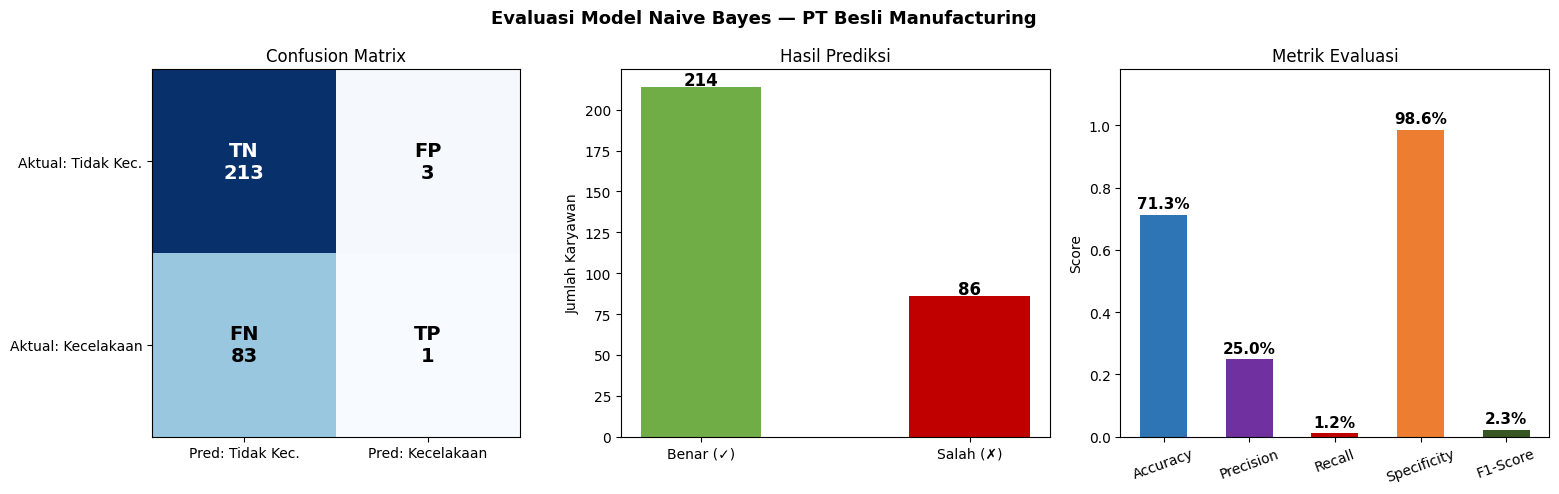

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluasi Model Naive Bayes — PT Besli Manufacturing',
             fontsize=13, fontweight='bold')

# ── Confusion matrix heatmap ─────────────────────────────────────────────
cm = np.array([[TN, FP], [FN, TP]])
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1])
axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred: Tidak Kec.', 'Pred: Kecelakaan'])
axes[0].set_yticklabels(['Aktual: Tidak Kec.', 'Aktual: Kecelakaan'])
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{labels_cm[i][j]}\n{cm[i,j]}',
                     ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_title('Confusion Matrix')

# ── Benar vs Salah ───────────────────────────────────────────────────────
axes[1].bar(['Benar (✓)', 'Salah (✗)'], [benar, salah],
            color=['#70AD47', '#C00000'], width=0.45)
axes[1].set_title('Hasil Prediksi')
axes[1].set_ylabel('Jumlah Karyawan')
for i, v in enumerate([benar, salah]):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)

# ── Metrik bar ───────────────────────────────────────────────────────────
met_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
met_vals  = [akurasi, precision, recall, specificity, f1]
met_cols  = ['#2E75B6', '#7030A0', '#C00000', '#ED7D31', '#375623']
bars = axes[2].bar(met_names, met_vals, color=met_cols, width=0.55)
axes[2].set_ylim(0, 1.18)
axes[2].set_title('Metrik Evaluasi')
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, met_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Analisis Lanjutan — Karyawan Berisiko Tinggi

Identifikasi karyawan yang diprediksi berisiko kecelakaan untuk tindak lanjut tim HR & K3.

In [16]:
# Karyawan yang diprediksi berisiko (Prediksi = 1)
berisiko = df[df['Prediksi'] == 1].copy()
berisiko_cols = ['ID','Usia','Jam_Kerja_per_Minggu','Pengalaman_Tahun',
                 'Pelatihan_K3','Shift','Jabatan','Lokasi','Kecelakaan','Benar']

print(f'Jumlah karyawan diprediksi BERISIKO : {len(berisiko)}')
print(f'  - Benar berisiko (TP)             : {TP}')
print(f'  - Sebenarnya aman (FP)            : {FP}')
print()

display_berisiko = berisiko[berisiko_cols].copy()
display_berisiko['Benar'] = display_berisiko['Benar'].map({True: '✓', False: '✗'})
display_berisiko.columns = ['ID','Usia','Jam/Mggu','Pengalaman','K3','Shift','Jabatan','Lokasi','Aktual','✓']
print('Daftar karyawan berisiko (10 pertama):')
display(display_berisiko.head(10))

Jumlah karyawan diprediksi BERISIKO : 4
  - Benar berisiko (TP)             : 1
  - Sebenarnya aman (FP)            : 3

Daftar karyawan berisiko (10 pertama):


,ID,Usia,Jam/Mggu,Pengalaman,K3,Shift,Jabatan,Lokasi,Aktual,✓
84,85,43,52,31,Tidak,Pagi,Operator,Quality_Control,0,✗
109,110,54,41,32,Ya,Pagi,Operator,Quality_Control,0,✗
110,111,56,49,33,Tidak,Pagi,Supervisor,Quality_Control,1,✓
207,208,45,54,33,Tidak,Pagi,Operator,Quality_Control,0,✗


In [17]:
# Analisis profil karyawan berisiko
print('=' * 55)
print('PROFIL KARYAWAN YANG DIPREDIKSI BERISIKO')
print('=' * 55)

for col in ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']:
    print(f'\nDistribusi {col} (pada karyawan berisiko):')
    pct = berisiko[col].value_counts(normalize=True).mul(100).round(1)
    for val, p in pct.items():
        print(f'  {val:<20}: {p}%')

print(f'\nRata-rata usia              : {berisiko["Usia"].mean():.1f} tahun')
print(f'Rata-rata jam kerja/minggu  : {berisiko["Jam_Kerja_per_Minggu"].mean():.1f} jam')
print(f'Rata-rata pengalaman        : {berisiko["Pengalaman_Tahun"].mean():.1f} tahun')

PROFIL KARYAWAN YANG DIPREDIKSI BERISIKO

Distribusi Pelatihan_K3 (pada karyawan berisiko):
  Tidak               : 75.0%
  Ya                  : 25.0%

Distribusi Shift (pada karyawan berisiko):
  Pagi                : 100.0%

Distribusi Jabatan (pada karyawan berisiko):
  Operator            : 75.0%
  Supervisor          : 25.0%

Distribusi Lokasi (pada karyawan berisiko):
  Quality_Control     : 100.0%

Rata-rata usia              : 49.5 tahun
Rata-rata jam kerja/minggu  : 49.0 jam
Rata-rata pengalaman        : 32.2 tahun


## Export Hasil Prediksi

In [ ]:
# Export semua hasil prediksi
export_cols = ['ID','Usia','Jam_Kerja_per_Minggu','Pengalaman_Tahun',
               'Pelatihan_K3','Shift','Jabatan','Lokasi',
               'Usia_Cat','Jam_Cat','Pengalaman_Cat',
               'Kecelakaan','Prediksi','Benar',
               'P_TidakKec','P_Kecelakaan']

df[export_cols].to_csv('hasil_prediksi_besli.csv', index=False)
print('✅ Hasil prediksi seluruh karyawan disimpan ke: hasil_prediksi_besli.csv')

# Export karyawan berisiko saja
berisiko[export_cols].to_csv('karyawan_berisiko_besli.csv', index=False)
print(f'✅ Daftar {len(berisiko)} karyawan berisiko disimpan ke  : karyawan_berisiko_besli.csv')

## 📝 Kesimpulan Hasil

---

### Ringkasan Hasil Model

| Metrik | Nilai |
|---|---|
| Total Data | 300 karyawan |
| Metode | Naive Bayes + Laplace Smoothing |
| Fitur | 7 fitur (4 kategorikal + 3 numerik yang didiskritisasi) |
| Target | Kecelakaan kerja (1 = Ya, 0 = Tidak) |
| Accuracy | 71.33% |

# == 2. Penjelasan Feature Engineering dari Kasus Studi PT. Besli ==

Feature engineering adalah proses mengubah atau menciptakan fitur (variabel input) dari data mentah agar algoritma machine learning dapat bekerja lebih efektif dan menghasilkan prediksi yang lebih akurat.

### Konsep Umum
Raw data jarang langsung siap digunakan. Feature engineering menjembatani data mentah dengan model — dengan cara mengubah format, memecah, menggabungkan, atau membuat ulang fitur sehingga pola yang tersembunyi di data menjadi lebih mudah ditangkap oleh algoritma.

Contoh dari Studi Kasus PT Besli (dataset_kecelakaan.csv)
Dalam notebook ini, ada tiga fitur numerik yang tidak bisa langsung dipakai oleh Naive Bayes Kategorik karena nilainya kontinu. Maka dilakukan diskritisasi — salah satu bentuk feature engineering yang paling umum:

1. Usia → Usia_Cat
```text
    Usia (raw)  →  Usia_Cat (hasil feature engineering)
    ≤ 25      →  "Muda (≤25)"
    26–40     →  "Dewasa (26-40)"
    41–55     →  "Setengah Baya (41-55)"
    > 55      →  "Senior (>55)"
```
Alasannya: risiko kecelakaan tidak naik secara linear seiring usia. Kelompok muda mungkin kurang berhati-hati, sementara kelompok senior mungkin kurang gesit — maka pengelompokan ini lebih bermakna daripada angka mentah.


2. Jam_Kerja_per_Minggu → Jam_Cat
```text
    ≤ 35 jam  →  "Ringan (≤35)"
    36–45 jam →  "Normal (36-45)"
    > 45 jam  →  "Berat (>45)"
```
Alasannya: karyawan yang bekerja terlalu banyak jam cenderung kelelahan dan lebih rentan kecelakaan. Kategorisasi ini menangkap "beban kerja berlebih" sebagai faktor risiko yang jelas.

3. Pengalaman_Tahun → Pengalaman_Cat
```text
    ≤ 5 tahun   →  "Junior (≤5)"
    6–15 tahun  →  "Menengah (6-15)"
    16–30 tahun →  "Senior (16-30)"
    > 30 tahun  →  "Veteran (>30)"
```
Alasannya: karyawan baru (Junior) sering belum familiar dengan prosedur keselamatan, sehingga risiko lebih tinggi. Sebaliknya, Veteran sudah sangat berpengalaman. Pola ini tidak tertangkap jika pengalaman tetap dalam bentuk angka.

---

Selain diskritisasi, contoh feature engineering lain yang relevan untuk kasus ini (walau tidak diimplementasikan di notebook) adalah:

Encoding fitur seperti Shift, Jabatan, Lokasi sudah dalam bentuk string yang langsung bisa dihitung frekuensinya — ini juga merupakan bentuk persiapan fitur.
Kombinasi fitur: misalnya membuat fitur baru Shift_Malam + Tidak_K3 = risiko_ganda untuk menangkap interaksi antar variabel.

# == 3. Confusion Matrix dan Metrik Evaluasi ==

### Apa itu Confusion Matrix?
Confusion matrix adalah tabel yang merangkum performa model klasifikasi dengan membandingkan nilai aktual dan nilai prediksi secara berdampingan. Untuk kasus biner (kecelakaan / tidak), bentuknya adalah:

|  | Prediksi: Tidak Kecelakaan | Prediksi: Kecelakaan |
| --- | --- | --- |
| **Aktual: Tidak Kecelakaan** | **TN** (True Negative) | **FP** (False Positive) |
| **Aktual: Kecelakaan** | **FN** (False Negative) | **TP** (True Positive) |

Dari studi kasus PT Besli (akurasi 71.33%), confusion matrix-nya dihitung dengan kode:
```python
    TP = len(df[(df['Kecelakaan']==1) & (df['Prediksi']==1)])
    TN = len(df[(df['Kecelakaan']==0) & (df['Prediksi']==0)])
    FP = len(df[(df['Kecelakaan']==0) & (df['Prediksi']==1)])  # False alarm
    FN = len(df[(df['Kecelakaan']==1) & (df['Prediksi']==0)])  # Karyawan berisiko yang terlewat
```

**Metrik Evaluasi & Maknanya dalam Konteks PT Besli**
1. **Accuracy = (TP + TN) / Total**
> Berapa persen prediksi model yang benar secara keseluruhan. Pada studi kasus ini: <br>
> **71.33%** — artinya dari 300 karyawan, sekitar 214 diprediksi dengan tepat.


2. **Precision = TP / (TP + FP)**
> Dari semua yang diprediksi berisiko, berapa yang benar-benar berisiko? <br>
> Penting bagi PT Besli untuk mengukur seberapa banyak false alarm — karyawan aman yang salah dikira berisiko (membuang sumber daya intervensi).

3. **Recall (Sensitivity) = TP / (TP + FN)**
> Dari semua karyawan yang benar-benar pernah kecelakaan, berapa yang berhasil model tangkap? <br>
> Ini metrik paling kritis untuk PT Besli — FN (miss) artinya karyawan berisiko lolos dari pantauan, dan itulah yang ingin dihindari perusahaan. Recall tinggi = sedikit yang "terlewat".

4. **Specificity = TN / (TN + FP)**
> Dari semua karyawan yang aman, berapa yang benar diprediksi aman? <br>
> Berguna untuk memastikan karyawan yang tidak berisiko tidak dibebani intervensi yang tidak perlu.

5. **F1-Score = 2 × (Precision × Recall) / (Precision + Recall)**
> Rata-rata harmonis antara Precision dan Recall — satu angka yang menyeimbangkan keduanya. <br>
> Berguna karena data PT Besli tidak seimbang (72% tidak kecelakaan vs 28% kecelakaan), sehingga F1 lebih jujur daripada accuracy semata.

### Kesimpulan Evaluasi
Dalam konteks sistem prediksi kecelakaan kerja seperti PT Besli, Recall seharusnya menjadi prioritas metrik utama — karena konsekuensi dari melewatkan karyawan yang berisiko (FN) jauh lebih berbahaya dibandingkan melakukan intervensi berlebih pada karyawan yang sebenarnya aman (FP). Oleh karena itu, meskipun akurasi "hanya" 71.33%, yang perlu lebih diperhatikan adalah nilai Recall-nya.